# CLUSTERING

In [2]:
# Cargar librerias
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Para mostrar gráficos en línea si usamos Jupyter
%matplotlib inline

In [3]:
# Cargar datos
path = os.path.join('df_final.csv')
df = pd.read_csv(path)

In [4]:
# Tamaño df
df.shape

(51707, 46)

In [5]:
# Tipo de columnas
print(df.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [6]:
# Visualizar primeras 10 filas
df.head(10)

,booked_at,checkin_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,travel_agency_name,...,Estacion_Estancia,Estacion_Reserva,zona_roja_mes,momento_checkin,total_personas_adult_y_niños,ratio_formularios,reservation_checkin_month_diff,estancia_en_festivo,estancia_en_finde,mes_checkin_numerico
0,2022-11-26 16:10:00,2023-01-01 12:00:00,36,1,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Autumn,0,Antes,1,1.000000,2,0,1,1
1,2022-12-21 17:27:00,2023-01-01 13:09:00,11,9,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Winter,0,Antes,1,1.000000,1,1,1,1
2,2022-09-21 19:46:00,2023-01-01 15:00:00,102,6,January,Sunday,2,4,channel_manager,Booking.com,...,Winter,Autumn,0,Antes,6,0.333333,4,1,1,1
3,2022-09-24 12:09:00,2023-01-01 15:00:00,99,1,January,Sunday,2,2,channel_manager,Booking.com,...,Winter,Autumn,1,Antes,4,0.500000,4,0,1,1
4,2022-10-18 07:12:00,2023-01-01 15:00:00,75,1,January,Sunday,4,0,channel_manager,Booking.com,...,Winter,Autumn,1,Antes,4,1.000000,3,0,1,1
5,2022-11-25 17:50:00,2023-01-01 15:00:00,37,1,January,Sunday,2,1,channel_manager,Booking.com,...,Winter,Autumn,0,NaN,3,0.000000,2,0,1,1
6,2022-11-26 04:10:00,2023-01-01 15:00:00,36,2,January,Sunday,3,0,channel_manager,Booking.com,...,Winter,Autumn,1,NaN,3,0.000000,2,0,1,1
7,2022-12-02 20:02:00,2023-01-01 15:00:00,30,1,January,Sunday,2,2,channel_manager,Booking.com,...,Winter,Winter,0,Antes,4,0.500000,1,0,1,1
8,2022-12-04 23:18:00,2023-01-01 15:00:00,28,2,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Winter,0,Durante,1,1.000000,1,0,1,1
9,2022-12-11 12:51:00,2023-01-01 15:00:00,21,7,January,Sunday,2,0,channel_manager,Booking.com,...,Winter,Winter,1,NaN,2,0.000000,1,1,1,1


In [7]:
# Columnas:
df.columns

Index(['booked_at', 'checkin_time', 'lead_time', 'lenght_of_stay',
       'checkin_month', 'checkin_day', 'adult_count', 'child_count', 'origin',
       'travel_agency_name', 'requested_category', 'requested_category_name',
       'asset', 'asset_type', 'brand', 'available_units', 'business_segment',
       'rate', 'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'returning_inhabitant', 'recurrence',
       'libere_community', 'bought_products', 'product_count',
       'reservation_net_value', 'total_adr', 'status', 'cancellation_reason',
       'cancellation_lead_time', 'City', 'Reserva_Dia_Semana',
       'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia',
       'Estacion_Reserva', 'zona_roja_mes', 'momento_checkin',
       'total_personas_adult_y_niños', 'ratio_formularios',
       'reservation_checkin_month_diff', 'estancia_en_festivo',
       'estancia_en_finde', 'mes_checkin_numerico'],
      dtype='object')

In [8]:
# Conversion de tipo de variables
df['all_entry_forms_completed'] = df['all_entry_forms_completed'].map({'yes': 1, 'no': 0, 1.0: 1}) #Binaria


### SELECCIÓN DE VARIABLES
#### 1. **Variables Cancelacion**: Principalmente se deben excluir aquellas variables que le daran infromacion al modelo que ese cliente vaya a cancelar (Checkin_time, ratio_cancelaciones....).<br>**2. Variables Ctaegoricas** : Convertir a variables dummies <br>3. **Variables Numericas:** Escalar los valores, con min max (Estandar escaler no!)

In [9]:
# Variable a usar y categorizar:

#------ NUMERICAS:
num_cols = [
    'lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
    'completed_entry_forms_count', 'product_count', 'reservation_net_value',
    'total_adr', 'reservation_checkin_month_diff', 'total_personas_adult_y_niños'
]

#Convertir a numericos
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convierte errores a NaN


#-------- CATEGORICAS:
# Representan categorías o clases
cat_cols = [
    'origin', 'travel_agency_name', 'requested_category', 'requested_category_name',
    'asset', 'asset_type', 'brand', 'business_segment', 'rate', 'rate_group_name',
    'rate_type', 'returning_inhabitant', 'recurrence', 'libere_community', 
    'bought_products', 'momento_checkin', 'City', 'Reserva_Dia_Semana', 
    'Estacion_Estancia', 'Estacion_Reserva'
]

#--------- BINARIAS:
# Ya son 0/1, no requieren escalado
bin_cols = [
    'estancia_en_festivo', 'estancia_en_finde', 'all_entry_forms_completed'
]
df_bin = df[bin_cols].astype(int)

In [10]:
print(df.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed           int64
returning_inhabitant               object
recurrence                        

In [11]:

cancellation_cols = [
    'checkin_time',
    'status',                  # Estado de la reserva (cancelled o no)
    'cancellation_reason',     # Motivo de cancelación
    'cancellation_lead_time',  # Días de anticipación de la cancelación
    'ratio_formularios',       # Relación de formularios completados (indica engagement)
    'Cancelacion_Dia_Semana',  # Día de la semana de la cancelación
    'Estacion_Cancelacion',    # Estación en la que se realizó la cancelación
    'zona_roja_mes',           # Indica mes de alta probabilidad de cancelación
    'zona_roja_estacion',       # Indica estación de alta probabilidad de cancelación
    'checkin_month',
    'checkin_day',
    'mes_checkin_numerico',
    'available_units'   #????????????????????????????????????
]
print(len(cancellation_cols))

13


Crear dfs para cada uno de estas categorias (Numericas, Categoricas, Binarias)

In [12]:
# NUmericas:
df_num = df[num_cols]
print("DataFrame numérico:", df_num.shape)

#Categoricas:
df_cat = df[cat_cols]
print("DataFrame categórico:", df_cat.shape)

#Binarias:
df_bin = df[bin_cols]
print("DataFrame binario:", df_bin.shape)

DataFrame numérico: (51707, 10)
DataFrame categórico: (51707, 20)
DataFrame binario: (51707, 3)


ESCALAR VARIABLES NUMERICAS

In [13]:
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=num_cols)
df_num_scaled

,lead_time,lenght_of_stay,adult_count,child_count,completed_entry_forms_count,product_count,reservation_net_value,total_adr,reservation_checkin_month_diff,total_personas_adult_y_niños
0,0.047461,0.012658,0.1,0.00,0.1,0.000000,0.015921,0.016100,0.100000,0.0
1,0.019868,0.113924,0.1,0.00,0.1,0.000000,0.117788,0.013238,0.066667,0.0
2,0.120309,0.075949,0.2,0.50,0.2,0.266667,0.755703,0.127367,0.166667,0.5
3,0.116998,0.012658,0.2,0.25,0.2,0.033333,0.186383,0.188481,0.166667,0.3
4,0.090508,0.012658,0.4,0.00,0.4,0.000000,0.077025,0.077892,0.133333,0.3
...,...,...,...,...,...,...,...,...,...,...
51702,0.094923,0.012658,0.4,0.00,0.4,0.000000,0.169612,0.171521,0.100000,0.3
51703,0.094923,0.012658,0.4,0.00,0.4,0.000000,0.169612,0.171521,0.100000,0.3
51704,0.090508,0.012658,0.5,0.00,0.5,0.000000,0.647325,0.654612,0.100000,0.4
51705,0.090508,0.012658,0.4,0.00,0.4,0.000000,0.732781,0.741030,0.100000,0.3


CONVERSION DE CATEGORICAS A DUMMIES

In [14]:
df_cat_dummies = pd.get_dummies(df_cat, drop_first=True)
df_cat_dummies

,recurrence,origin_direct_channel,origin_email,origin_in_person,origin_telephone,travel_agency_name_AVORIS RETAIL DIVISION S.L. (Buhaira Empresas),travel_agency_name_Airbnb,travel_agency_name_Analog Devices C/O SilverDoor Limited,travel_agency_name_Avoris Retail Division S.L.,travel_agency_name_Avoris Retail Division SL (Oficina 1807),...,Reserva_Dia_Semana_Sunday,Reserva_Dia_Semana_Thursday,Reserva_Dia_Semana_Tuesday,Reserva_Dia_Semana_Wednesday,Estacion_Estancia_Spring,Estacion_Estancia_Summer,Estacion_Estancia_Winter,Estacion_Reserva_Spring,Estacion_Reserva_Summer,Estacion_Reserva_Winter
0,4,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
2,1,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
3,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,1,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51702,1,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
51703,1,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
51704,1,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
51705,1,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [15]:
# Data set final para clustering:
df_clustering = pd.concat([df_num_scaled, df_cat_dummies, df_bin], axis=1)
print("Dimensiones del dataset final para clustering:", df_clustering.shape)

# Se peude pasar a sparse matrix.

Dimensiones del dataset final para clustering: (51707, 325)


# PCA

- PCA requiere variables numéricas
- Distancias euclídeas → escalar antes 
- Usamos StandardScaler SOLO para PCA, no para clustering final

In [16]:
# Dataset solo numérico / binario para PCA
df_pca = pd.concat([
    df_num_scaled,   # ya escaladas con MinMax
    df_bin            # binarias
], axis=1)

print(df_pca.shape)


(51707, 13)


In [ ]:
# Ajustar PCA sin fijar n_components
pca = PCA(random_state=42)
X_pca_full = pca.fit_transform(df_pca)


# # En caso de que queramos con 30 componente principales. 
# pca = PCA(n_components=30, random_state=42)
# df_pca_30 = pca.fit_transform(df_pca)
# print("Shape PCA:", df_pca_30.shape)


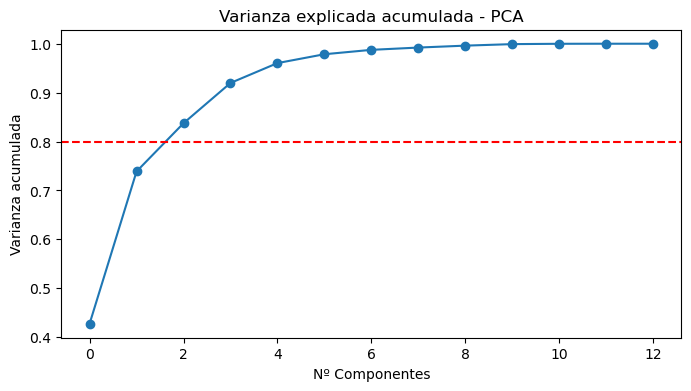

In [31]:
# Varianza explciada acumulada
explained_variance  = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,4))
plt.plot(explained_variance, marker='o')
plt.axhline(0.8, linestyle='--', color='red')
plt.xlabel("Nº Componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada acumulada - PCA")
plt.show()

In [ ]:
#NO
#Elegir el numero optimo de componentes (99%)
n_components_optimo = np.argmax(explained_variance  >= 0.99) + 1

print("Número óptimo de componentes:", n_components_optimo)
print("Varianza explicada:", explained_variance [n_components_optimo - 1])


Número óptimo de componentes: 8
Varianza explicada: 0.9921470529208791


In [ ]:
#NO 
# PCA final con el numero optimo
pca_opt = PCA(n_components=n_components_optimo, random_state=42)
X_pca = pca_opt.fit_transform(df_pca)

print("Shape PCA:", X_pca.shape)


Shape PCA: (51707, 8)


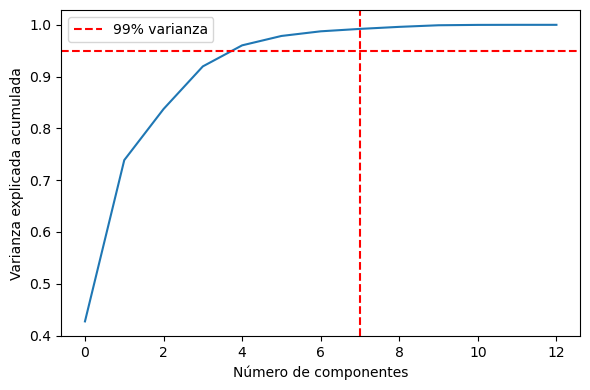

In [ ]:
#Graficar para validar visualmente
plt.figure(figsize=(6,4))
plt.plot(explained_variance )
plt.axhline(0.95, color='red', linestyle='--', label='99% varianza')
plt.axvline(n_components_optimo - 1, color='red', linestyle='--')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.legend()
plt.tight_layout()
plt.show()


## MODELOS (K-Means, Jerarquico, BDSCAN)

### 1º Modelo: K-means

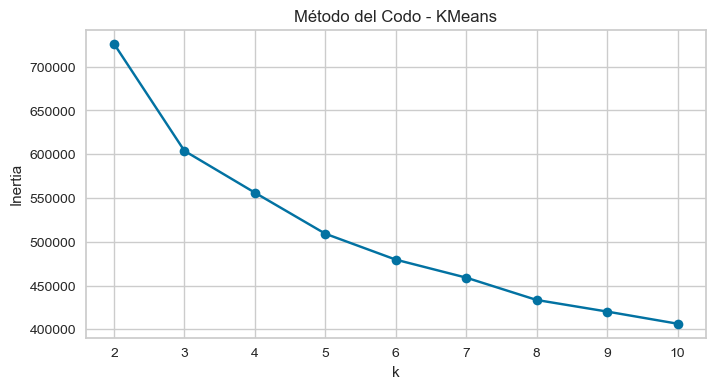

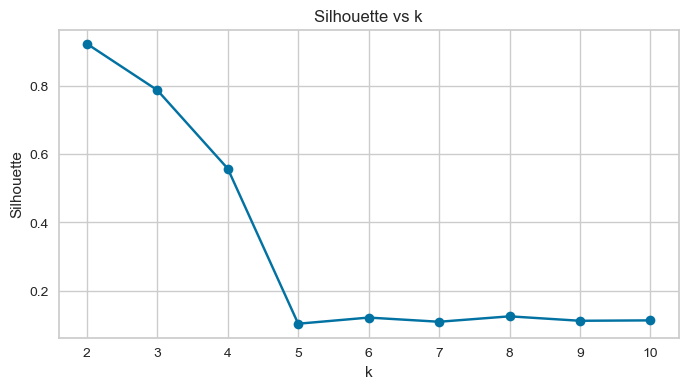

Silhouette KMeans (k=4): 0.5580


In [ ]:
# Probamos distintos k (2 a 10)
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(df_clustering)
    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(df_clustering, etiquetas))

# Método del codo
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Método del Codo - KMeans")
plt.show()

# Índice de Silueta
plt.figure(figsize=(8,4))
plt.plot(k_values, silhouettes, '-o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k")
plt.show()

# Elegimos k_final según el codo y silhouette
k_final = 4
kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(df_clustering)




In [ ]:
# Shilhouette de K-Means
sil_kmeans = silhouette_score(df_clustering, labels_kmeans)
print(f"Silhouette KMeans (k={k_final}): {sil_kmeans:.4f}")

### 1.1º K-Means + GRIDSEARCH + cv

In [35]:
#funciones de validacion
def clustering_metrics(X, labels):
    """
    Calcula métricas internas de clustering
    """
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan
    
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    return sil, db, ch


In [37]:
from sklearn.cluster import KMeans
from sklearn.model_selection import ParameterGrid


def gridsearch_kmeans(X, param_grid):
    results = []
    
    for params in ParameterGrid(param_grid):
        model = KMeans(**params, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        
        sil, db, ch = clustering_metrics(X, labels)
        
        results.append({
            **params,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })
    
    return pd.DataFrame(results)


#Ejecuta GridSearch
param_grid_kmeans = {
    'n_clusters': range(2, 11)
}

results_kmeans = gridsearch_kmeans(X_pca_full, param_grid_kmeans)
results_kmeans.sort_values('silhouette', ascending=False).head()



,n_clusters,silhouette,davies_bouldin,calinski_harabasz
3,5,0.619816,0.764605,47367.633136
2,4,0.598632,0.711674,48240.574067
4,6,0.535756,0.897337,43793.068531
1,3,0.533558,0.859945,45102.707347
8,10,0.489059,0.937097,41129.242804


In [ ]:
#Mejor modelo
best_k = results_kmeans.loc[
    results_kmeans['silhouette'].idxmax(), 'n_clusters'
]

kmeans_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_kmeans = kmeans_best.fit_predict(X_pca_30)


### 2º Modelo: Jerarquico

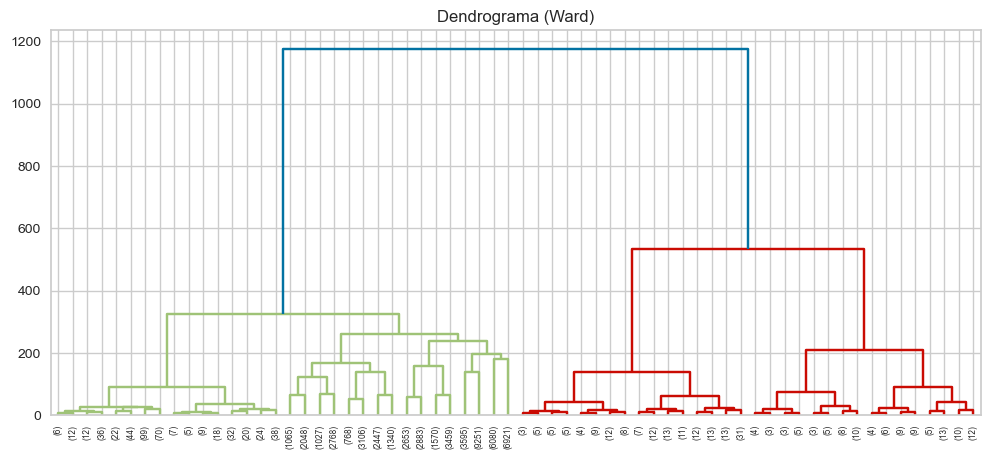

: 

: 

In [80]:
# Dendrograma
Z = linkage(df_clustering, method='ward')
plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrograma (Ward)")
plt.show()

# Clustering final con k igual al del método del codo
k_hier = 4
agglo = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
labels_agglo = agglo.fit_predict(df_clustering)

sil_agglo = silhouette_score(df_clustering, labels_agglo)
print(f"Silhouette Agglomerative (k={k_hier}): {sil_agglo:.4f}")


### 3º Modelo: BDSCAN

In [ ]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels_dbscan = dbscan.fit_predict(df_clustering)

# Para silueta, debe haber >1 cluster
if len(set(labels_dbscan)) > 1:
    sil_dbscan = silhouette_score(df_clustering, labels_dbscan)
else:
    sil_dbscan = -1
print(f"Silhouette DBSCAN: {sil_dbscan:.4f}")


ValueError: could not convert string to float: 'mes_checkin_numerico'

### EVALUACIÓN COMPARATIVA DE MODELOS

In [ ]:
# Métricas de Silhouette
sil_scores = {
    'KMeans': sil_kmeans,
    'Agglomerative': sil_agglo,
    'DBSCAN': sil_dbscan
}
print("Coeficientes de Silhouette de cada modelo:")
print(sil_scores)

# Elegimos el mejor modelo
best_model = max(sil_scores, key=sil_scores.get)
print(f"Mejor modelo según Silhouette: {best_model}")


### Añadir cluster al DF como dummies

In [ ]:
if best_model == 'KMeans':
    best_labels = labels_kmeans
elif best_model == 'Agglomerative':
    best_labels = labels_agglo
else:
    best_labels = labels_dbscan

# Añadir cluster al df original
df['cluster'] = best_labels

# Crear columnas dummies
df_clusters = pd.get_dummies(df['cluster'], prefix='cluster')
df_final_with_clusters = pd.concat([df, df_clusters], axis=1)

print(df_final_with_clusters.head())
print("Columnas de clusters dummies añadidas:", df_clusters.columns.tolist())
